# Kredi Kartı Dolandırıcılığı Tespiti

Önceki egzersizler, bir sinir ağının tüm farklı bileşenlerine daha yakından bakmanızı sağladı:
* sıralı (sequential) yoğun (Dense) bir Sinir Ağı mimarisi,
* derleme (compilation) yöntemi,
* modelin eğitilmesi (fitting).

Şimdi **çok fazla veri içeren** gerçek hayat bir veri seti üzerinde çalışalım!

**Veri seti: `Kredi Kartı İşlemleri (Credit Card Transactions)`**

Bu açık uçlu challenge’da, **kredi kartı işlemlerinden elde edilmiş verilerle** çalışacaksınız.

Bu veriler **hassas** olduğu için, toplam 31 sütundan yalnızca 3’ü bilinmektedir; geri kalanlar verileri **anonimleştirmek** amacıyla dönüştürülmüştür (aslında bunlar, orijinal verilerin **PCA projeksiyonlarıdır**).

Bilinen 3 sütun şunlardır:

* `TIME`: İşlemin, veri setindeki ilk işleme göre geçen süresi  
* `AMOUNT`: İşlem tutarı  
* `CLASS` (hedef değişkenimiz):
    * `0 : geçerli işlem`
    * `1 : sahte (fraud) işlem`

❓ **Soru** ❓ Veri setini indirerek başlayın:
* Kaggle üzerinden: [buradan](https://www.kaggle.com/mlg-ulb/creditcardfraud)
* veya bizim URL’mizden: [buradan](https://d32aokrjazspmn.cloudfront.net/materials/creditcard.csv)

Veriyi yükleyerek `X` ve `y` değişkenlerini oluşturun.

In [1]:
# SENİN KODUN BURAYA
import pandas as pd

data = pd.read_csv("data/creditcard.csv")
data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
X = data.drop(columns=['Class'], axis=1).values
y = data["Class"]

In [3]:
type(X)

numpy.ndarray

## 1. Sınıfların yeniden dengelenmesi

In [4]:
# Sınıf dengesini kontrol edelim
pd.Series(y).value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

☝️ Bu `fraud detection` (sahtekârlık tespiti) challenge’ında **sınıflar aşırı derecede dengesizdir**:
* %99.8 normal işlemler
* %0.2 sahte (fraud) işlemler

**Ciddi yeniden dengeleme (rebalancing) stratejileri uygulamazsak sahtekârlık vakalarını tespit edemeyiz!**

❓ **Soru** ❓
1. **Önce**, veri setinizden üç ayrı bölme oluşturun: `Train / Val / Test`.  
   Doğrulama (validation) ve test setlerinin **dengesiz** kalması son derece önemlidir; böylece modeli değerlendirirken gerçek koşullar korunur ve veri sızıntısı (data leakage) oluşmaz. Test setinizi bu notebook’un **en son hücresine kadar saklayın**!

&nbsp;

2. **İkinci olarak**, yalnızca eğitim setinizi (training set) yeniden dengeleyin. Birçok seçeneğiniz var:

- Azınlık sınıfını rastgele oversample etmek (düz NumPy fonksiyonlarıyla).  
  *(En iyi seçenek değildir; çünkü satırları kopyalayarak veri sızıntısı yaratır.)*
- <a href="https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/">**`Synthetic Minority Oversampling Technique - SMOTE`**</a> kullanarak, mevcut gözlemleri ağırlıklandırıp yeni veri noktaları üretmek
- Buna ek olarak, çoğunluk sınıfını bir miktar küçültmek için  
  <a href="https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/">**`RandomUnderSampler`**</a> da deneyebilirsiniz

In [5]:
# SENİN KODUN BURAYA
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.30, random_state=42, stratify=y_train)


In [6]:
print(f"train {X_train.shape}")
print(f"test {X_test.shape}")
print(f"val {X_val.shape}")

train (139554, 30)
test (85443, 30)
val (59810, 30)


In [ ]:
# !pip install imbalanced-learn
#from imblearn.over_sampling import SMOTE
#
#smote = SMOTE(random_state=42)
#X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
#
#print(y_train.value_counts())
#print(y_train_resampled.value_counts())

In [ ]:
#from imblearn.under_sampling import RandomUnderSampler
#
#rus = RandomUnderSampler(random_state=42)
#
#X_train_under, y_train_under = rus.fit_resample(
#    X_train,
#    y_train
#)
#print(y_train.value_counts())
#print(y_train_under.value_counts())#

In [ ]:
#rus = RandomUnderSampler(sampling_strategy=0.5)
#X_under, y_under = rus.fit_resample(X_train, y_train)
#
#smote = SMOTE(random_state=42)
#X_balanced, y_balanced = smote.fit_resample(X_under, y_under)
#print(y_train.value_counts())
#print(y_balanced.value_counts())#

In [7]:
# Her bölünmede kaç "dolandırıcılık" örneği var?
import numpy as np
print(np.sum(y_train[y_train == 1]))
print(np.sum(y_val[y_val == 1]))
print(np.sum(y_test[y_test == 1]))

print("-"*100)

print(f"Eğitim setinde {pd.Series(y_train).value_counts()[1]} dolandırıcılık işlemi var")
print(f"Doğrulama setinde {pd.Series(y_val).value_counts()[1]} dolandırıcılık işlemi var")
print(f"Test setinde {pd.Series(y_test).value_counts()[1]} dolandırıcılık işlemi var")

241
103
148
----------------------------------------------------------------------------------------------------
Eğitim setinde 241 dolandırıcılık işlemi var
Doğrulama setinde 103 dolandırıcılık işlemi var
Test setinde 148 dolandırıcılık işlemi var


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn import set_config
from imblearn.pipeline import Pipeline

over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.33)
set_config(display='diagram')

steps =  [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)
pipeline

Pipeline(steps=[('o', SMOTE(sampling_strategy=0.1)),
                ('u', RandomUnderSampler(sampling_strategy=0.33))])

In [10]:
X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train, y_train)
print(f"X_train_resampled shape {X_train_resampled.shape}")
print(f"y_train_resampled {y_train_resampled.shape}")

X_train_resampled shape (56146, 30)
y_train_resampled (56146,)


In [12]:
# Yeniden örneklenmiş veriyi emin olmak için yeniden karıştır

stacked_resampled_data = np.hstack([X_train_resampled, y_train_resampled.to_numpy().reshape(-1,1)])
np.random.shuffle(stacked_resampled_data)

X_train_resampled = stacked_resampled_data[:,:30]
y_train_resampled = stacked_resampled_data[:,-1]

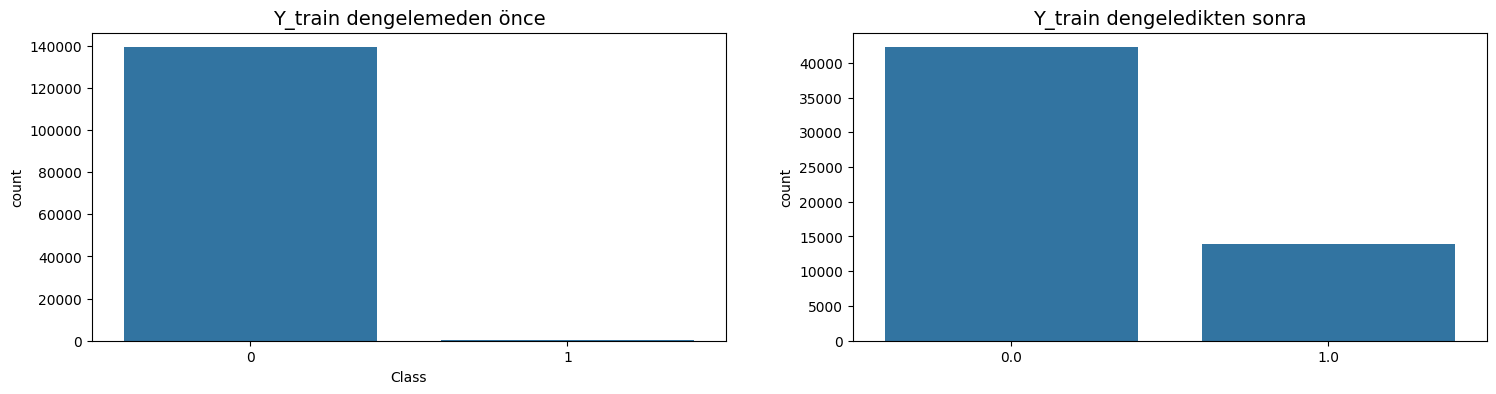

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(18,4))

sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title('Y_train dengelemeden önce', fontsize=14)

sns.countplot(x=y_train_resampled, ax=ax[1])
ax[1].set_title('Y_train dengeledikten sonra', fontsize=14);

## 2. Sinir Ağı yinelemeleri

Sınıflarınızı yeniden dengelediğinize göre, test puanınızı optimize etmek için bir sinir ağı uyarlayın. Aşağıdaki ipuçlarını kullanmaktan çekinmeyin:

- Girişlerinizi normalleştirin!
    - Modelinizdeki ön işlemeyi “boru hattı” haline getirmek için tercihen model içinde bir [`Normalization`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization) katmanı kullanın. 
    - Veya modelinizin dışında sklearn'in [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) öğesini kullanın, `X_train`, `X_val` ve `X_test` öğelerini uygulayın.
- Modelinizi aşırı uyumlu hale getirin, ardından aşağıdakileri kullanarak düzenleyin:
- Erken Durdurma kriterleri
- [`Dropout`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) katmanları
    - veya [`düzenleyiciler`](https://www.tensorflow.org/api_docs/python/tf/keras/regularizers) katmanları
- 🚨 İzlemek istediğiniz metrikleri ve kullanmak istediğiniz kayıp fonksiyonunu dikkatlice düşünün!

In [15]:
from keras.metrics import Recall, Precision, AUC

metrics = [
    Recall(name='recall'),
    Precision(name='precision'),
    AUC(name='prc', curve='PR'),  # precision-recall curve
]

In [ ]:
# SENİN KODUN BURAYA
from tensorflow.keras.layers import Normalization
from tensorflow.keras.metrics import Recall, Precision
from keras import models
from keras.layers import Dense, Dropout
from keras.optimizers import Adam


def init_model():
    input_shape = X_train_resampled.shape[1:]
    normalizer = Normalization()
    normalizer.adapt(X_train_resampled)
    
    model = models.Sequential()
    model.add(normalizer)
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=metrics
    )
    return model


In [19]:
model = init_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (56146, 30)            │            61 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (248.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 61 (248.00 B)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=10,
    monitor='val_recall', # Dolandırıcılık işlemlerini gerçekten tespit etmek 
    restore_best_weights=True
)
history = model.fit(X_train_resampled, y_train_resampled,
                    validation_data=(X_val, y_val),
                    epochs=100,
                    batch_size=64, # Dolandırıcılık işlemlerini içerme şansı elde etmek için yeterince büyük
                    callbacks=[early_stop], shuffle=True)

Epoch 1/100


ValueError: Could not interpret loss identifier: binary_crossen

### 🧪 Kodunu Test Et

Orijinal dengesiz veri kümesinin (`X_test`, `y_test`) temsil edici bir örneğinde gerçek test performansınızın altında kalan sonuçları `precision` ve `recall` değişkenlerine kaydedin.

In [ ]:
# SENİN KODUN BURAYA

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('solution',
    precision=precision,
    recall=recall,
    fraud_number=len(y_test[y_test == 1]),
    non_fraud_number=len(y_test[y_test == 0]),
)

result.write()
print(result.check())

## 🏁 İsteğe bağlı: Bu zorluk için Google'ın çözümünü okuyun
Bu oturumdaki tüm zorlukları tamamladığınız için tebrikler!

Son olarak, Google'ın kendi çözümünü doğrudan [Colab'da buradan](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/structured_data/imbalanced_data.ipynb) okuyun. 

İlginç teknikler ve en iyi uygulamaları keşfedeceksiniz.